In [6]:
# Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    OrdinalEncoder,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import joblib

In [7]:
# Charger le dataset
data_employee = pd.read_csv('../datasets/employee_satisfaction.csv')
# data_employee = data_employee.dropna()
data_employee.head()

,ID_Employe,Age,Sexe,Departement,Annees_Experience,Niveau_Etudes,Salaire_Mensuel_BIF,Travail_A_Distance,Heures_Supplementaires,Heures_Formation,Anciennete_Entreprise,Nombre_Promotions,Evaluation_Performance,Equilibre_Vie_Travail,Satisfaction_Salaire,Nombre_Absences,Satisfait
0,1,58.0,Homme,Marketing,12.0,Licence,2804177.0,Oui,13.0,95.0,8.0,0.0,3.0,Bon,Insatisfait,16.0,Oui
1,2,48.0,Femme,Marketing,NaN,Master,6000000.0,Non,12.0,48.0,10.0,4.0,1.0,Moyen,NaN,8.0,Non
2,3,34.0,Femme,Administration,16.0,NaN,4147951.0,Non,6.0,6.0,1.0,0.0,5.0,Très mauvais,Neutre,13.0,Non
3,4,27.0,Femme,Production,3.0,Licence,896874.0,Non,14.0,109.0,2.0,0.0,5.0,Moyen,Très insatisfait,16.0,Non
4,5,NaN,Femme,Administration,11.0,Master,3062453.0,Non,18.0,NaN,11.0,2.0,3.0,NaN,Très satisfait,28.0,Oui


In [8]:
# Vérifier les informations du dataset
data_employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Employe              510 non-null    int64  
 1   Age                     485 non-null    float64
 2   Sexe                    485 non-null    object 
 3   Departement             485 non-null    object 
 4   Annees_Experience       485 non-null    float64
 5   Niveau_Etudes           485 non-null    object 
 6   Salaire_Mensuel_BIF     485 non-null    float64
 7   Travail_A_Distance      485 non-null    object 
 8   Heures_Supplementaires  485 non-null    float64
 9   Heures_Formation        485 non-null    float64
 10  Anciennete_Entreprise   485 non-null    float64
 11  Nombre_Promotions       485 non-null    float64
 12  Evaluation_Performance  485 non-null    float64
 13  Equilibre_Vie_Travail   485 non-null    object 
 14  Satisfaction_Salaire    485 non-null    ob

In [9]:
# Vérifier les valeurs manquantes
data_employee.isnull().sum()

ID_Employe                 0
Age                       25
Sexe                      25
Departement               25
Annees_Experience         25
Niveau_Etudes             25
Salaire_Mensuel_BIF       25
Travail_A_Distance        25
Heures_Supplementaires    25
Heures_Formation          25
Anciennete_Entreprise     25
Nombre_Promotions         25
Evaluation_Performance    25
Equilibre_Vie_Travail     25
Satisfaction_Salaire      25
Nombre_Absences           25
Satisfait                  0
dtype: int64

In [ ]:
# Nettoyer les données

# Colonnes numeriques
numeric_columns = data_employee.select_dtypes(include='number')

for col in numeric_columns:
    data_employee[col] = data_employee[col].fillna(
        data_employee[col].mean()
    )

In [11]:
# Colonnes categorielles
numeric_columns = data_employee.select_dtypes(include='object')

for col in numeric_columns:
    data_employee[col] = data_employee[col].fillna(
        data_employee[col].mode()[0]
    )

In [12]:
# Verification
data_employee.isnull().sum()

ID_Employe                0
Age                       0
Sexe                      0
Departement               0
Annees_Experience         0
Niveau_Etudes             0
Salaire_Mensuel_BIF       0
Travail_A_Distance        0
Heures_Supplementaires    0
Heures_Formation          0
Anciennete_Entreprise     0
Nombre_Promotions         0
Evaluation_Performance    0
Equilibre_Vie_Travail     0
Satisfaction_Salaire      0
Nombre_Absences           0
Satisfait                 0
dtype: int64

In [13]:
# Encoder les variables catégorielles

# Encodage de la variable cible
data_employee["Satisfait"] = data_employee["Satisfait"].map({
    "Non":0,
    "Oui":1
})

In [14]:
# Définition des colonnes
ordinal_features = [
    "Niveau_Etudes",
    "Equilibre_Vie_Travail",
    "Satisfaction_Salaire"
]

binary_features = [
    "Sexe",
    "Travail_A_Distance"
]

onehot_features = [
    "Departement"
]

In [23]:
# Définir l'ordre des variables ordinales
ordinal_categories = [
    ["Secondaire", "Licence", "Master", "Doctorat"],
    ["Très mauvais", "Mauvais", "Moyen", "Bon", "Excellent"],
    ["Très insatisfait", "Insatisfait", "Neutre", "Satisfait", "Très satisfait"]
]

In [24]:
# Preprocesseur
preprocessor = ColumnTransformer(

    transformers=[

        (
            "ordinal",
            OrdinalEncoder(
                categories=ordinal_categories
            ),
            ordinal_features
        ),

        (
            "binary",
            OrdinalEncoder(),
            binary_features
        ),

        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            onehot_features
        )

    ],

    remainder="passthrough"
)

In [ ]:
# Créer X et y
X = data_employee.drop(
    columns=[
        "ID_Employe",
        "Satisfait"
    ]
)

y = data_employee["Satisfait"]

In [21]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
# Entraîner un modèle 
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(
    X_train,
    y_train
)

/usr/lib/python3/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Secondaire',
                                                                              'Licence',
                                                                              'Master',
                                                                              'Doctorat'],
                                                                             ['Très '
                                                                              'mauvais',
                                                                              'Mauvais',
                                                                              'Moyen',
                                                                              'Bon',
                                                                              'Excellent'],
                                                                             ['Très '
                                                                              'insatisfait',
                                                                              'Insatisfait',
                                                                              'Neutre',
                                                                              'Satisfait',
                                                                              'Très '
                                                                              'satisfait']]),
                                                  ['Niveau_Etudes',
                                                   'Equilibre_Vie_Travail',
                                                   'Satisfaction_Salaire']),
                                                 ('binary', OrdinalEncoder(),
                                                  ['Sexe',
                                                   'Travail_A_Distance']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Departement'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [26]:
# Entraîner un modèle 
tree_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42
    ))
])

tree_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(categories=[['Secondaire',
                                                                              'Licence',
                                                                              'Master',
                                                                              'Doctorat'],
                                                                             ['Très '
                                                                              'mauvais',
                                                                              'Mauvais',
                                                                              'Moyen',
                                                                              'Bon',
                                                                              'Excellent'],
                                                                             ['Très '
                                                                              'insatisfait',
                                                                              'Insatisfait',
                                                                              'Neutre',
                                                                              'Satisfait',
                                                                              'Très '
                                                                              'satisfait']]),
                                                  ['Niveau_Etudes',
                                                   'Equilibre_Vie_Travail',
                                                   'Satisfaction_Salaire']),
                                                 ('binary', OrdinalEncoder(),
                                                  ['Sexe',
                                                   'Travail_A_Distance']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Departement'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [27]:
# Comparer les deux modèles
y_pred_log = logistic_model.predict(X_test)
y_pred_tree = tree_model.predict(X_test)

In [28]:
# Évaluer — Accuracy
accuracy_log = accuracy_score(y_test, y_pred_log)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("Accuracy Logistic :", accuracy_log)
print("Accuracy Tree :", accuracy_tree)

Accuracy Logistic : 0.8431372549019608
Accuracy Tree : 0.7156862745098039


In [29]:
# Precision
precision_log = precision_score(
    y_test,
    y_pred_log
)

precision_tree = precision_score(
    y_test,
    y_pred_tree
)

print("Precision Logistic :", precision_log)
print("Precision Tree :", precision_tree)

Precision Logistic : 0.8813559322033898
Precision Tree : 0.7758620689655172


In [30]:
# Recall
recall_log = recall_score(
    y_test,
    y_pred_log
)

recall_tree = recall_score(
    y_test,
    y_pred_tree
)

print("Recall Logistic :", recall_log)
print("Recall Tree :", recall_tree)

Recall Logistic : 0.8524590163934426
Recall Tree : 0.7377049180327869


In [31]:
# F1-score
f1_log = f1_score(
    y_test,
    y_pred_log
)

f1_tree = f1_score(
    y_test,
    y_pred_tree
)

print("F1 Logistic :", f1_log)

print("F1 Tree :", f1_tree)

F1 Logistic : 0.8666666666666667
F1 Tree : 0.7563025210084033


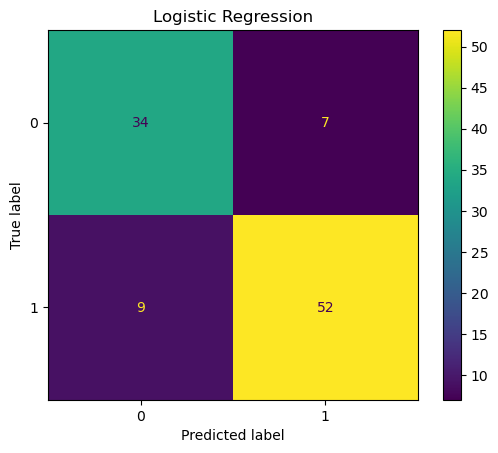

In [32]:
# Matrice de confusion

# Régression Logistique
cm_log = confusion_matrix(
    y_test,
    y_pred_log
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log
).plot()

plt.title("Logistic Regression")

plt.show()

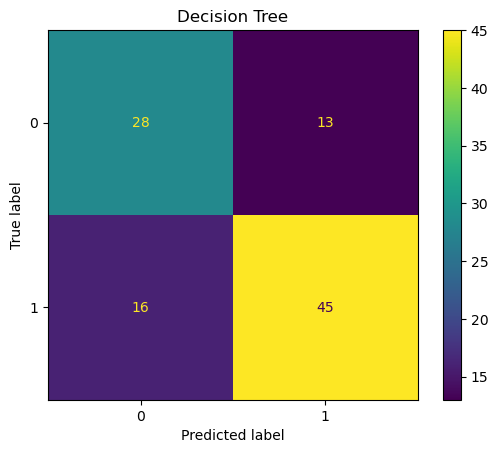

In [34]:
# Arbre de décision
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree
).plot()

plt.title("Decision Tree")
plt.show()

In [35]:
# Rapport de classification
# Logistic Regression
print(
    classification_report(
        y_test,
        y_pred_log
    )
)

              precision    recall  f1-score   support

           0       0.79      0.83      0.81        41
           1       0.88      0.85      0.87        61

    accuracy                           0.84       102
   macro avg       0.84      0.84      0.84       102
weighted avg       0.84      0.84      0.84       102



In [37]:
# Decision Tree
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

              precision    recall  f1-score   support

           0       0.64      0.68      0.66        41
           1       0.78      0.74      0.76        61

    accuracy                           0.72       102
   macro avg       0.71      0.71      0.71       102
weighted avg       0.72      0.72      0.72       102



In [38]:
# Sauvegarder le meilleur modèle
if f1_log >= f1_tree:

    best_model = logistic_model
    model_name = "Logistic Regression"

else:

    best_model = tree_model
    model_name = "Decision Tree"

In [39]:
# Sauvegarde

joblib.dump(
    best_model,
    "../models/employee_classifier.pkl"
)

print(f"Le meilleur modèle ({model_name}) a été sauvegardé.")

Le meilleur modèle (Logistic Regression) a été sauvegardé.


Interprétation finale

Après l'entraînement :

Accuracy : proportion totale de prédictions correctes.

Precision : parmi les employés prédits satisfaits, combien le sont réellement.

Recall : parmi les employés réellement satisfaits, combien ont été correctement détectés.

F1-score : moyenne harmonique entre la précision et le rappel ; c'est généralement la métrique à privilégier si les classes sont déséquilibrées.

Matrice de confusion : montre le nombre de vrais positifs, vrais négatifs, faux positifs et faux négatifs.

Rapport de classification : synthétise toutes ces métriques par classe et permet de comparer objectivement les deux modèles avant de choisir celui à sauvegarder.